In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('train.csv' , usecols=['Age' , 'Fare' , 'Survived'])

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


# Mean and Median Imputation

In [5]:
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
dtype: float64

In [6]:
x = df.drop(columns= ['Survived'])
y = df['Survived']

In [7]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size= 0.2 , random_state= 2)

In [8]:
x_train.shape , x_test.shape

((712, 2), (179, 2))

In [9]:
x_train.isnull().mean()

Age     0.207865
Fare    0.000000
dtype: float64

In [10]:
mean_age = x_train['Age'].mean()
median_age = x_train['Age'].median()

In [11]:
x_train['Age_Mean'] = x_train['Age'].fillna(mean_age)
x_train['Age_Median'] = x_train['Age'].fillna(median_age)

In [12]:
x_train

,Age,Fare,Age_Mean,Age_Median
30,40.0,27.7208,40.000000,40.00
10,4.0,16.7000,4.000000,4.00
873,47.0,9.0000,47.000000,47.00
182,9.0,31.3875,9.000000,9.00
876,20.0,9.8458,20.000000,20.00
...,...,...,...,...
534,30.0,8.6625,30.000000,30.00
584,NaN,8.7125,29.785904,28.75
493,71.0,49.5042,71.000000,71.00
527,NaN,221.7792,29.785904,28.75


In [14]:
print('Orignal Age variable Variance : ' , x_train['Age'].var())
print('Age  Variance after mean imputation : ' , x_train['Age_Mean'].var())
print('Age  Variance after median imputation : ' , x_train['Age_Median'].var())

Orignal Age variable Variance :  204.34951339046142
Age  Variance after mean imputation :  161.81262452718676
Age  Variance after median imputation :  161.98956633460548


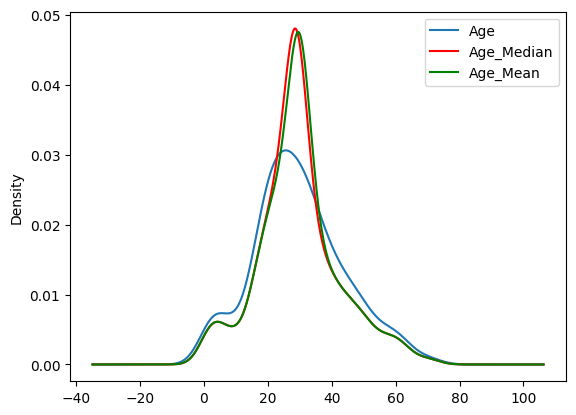

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111)
# Orignal variable distribution
x_train['Age'].plot(kind = 'kde' , ax=ax)
# variable imputed with the median
x_train['Age_Median'].plot(kind = 'kde' , ax=ax , color = 'red')
# variable imputed with the mean
x_train['Age_Mean'].plot(kind = 'kde' , ax =ax , color = 'green')
lines , labels = ax.get_legend_handles_labels()
ax.legend(lines,labels , loc = 'best')

In [16]:
x_train.cov()

,Age,Fare,Age_Mean,Age_Median
Age,204.349513,71.512440,204.349513,204.349513
Fare,71.512440,2368.246832,56.626587,58.986531
Age_Mean,204.349513,56.626587,161.812625,161.812625
Age_Median,204.349513,58.986531,161.812625,161.989566


In [17]:
x_train.corr()

,Age,Fare,Age_Mean,Age_Median
Age,1.000000,0.095814,1.000000,1.000000
Fare,0.095814,1.000000,0.091475,0.095235
Age_Mean,1.000000,0.091475,1.000000,0.999454
Age_Median,1.000000,0.095235,0.999454,1.000000


<Axes: >

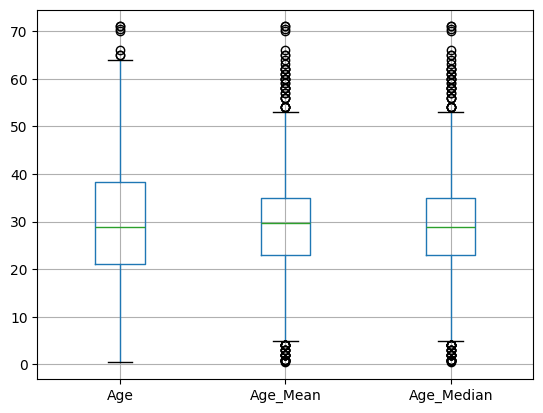

In [18]:
x_train[['Age' , 'Age_Mean' , 'Age_Median']].boxplot()

# Using Sklearn

In [19]:
imputer1 = SimpleImputer(strategy='mean')
imputer2 = SimpleImputer(strategy='median')

In [20]:
trf = ColumnTransformer([
    ('imputer1' , imputer1 , ['Age']),
    ('imputer2' , imputer2 , ['Age'])
],remainder='passthrough')

In [21]:
trf.fit(x_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


In [22]:
trf.named_transformers_['imputer1'].statistics_

array([29.78590426])

# Arbitrary Value Imputation

In [23]:
x_train['Age_99'] = x_train['Age'].fillna(99)
x_train['Age_Minus_1'] = x_train['Age'].fillna(-1)

In [25]:
x_train.sample(5)

,Age,Fare,Age_Mean,Age_Median,Age_99,Age_Minus_1
697,NaN,7.7333,29.785904,28.75,99.0,-1.0
459,NaN,7.7500,29.785904,28.75,99.0,-1.0
735,28.5,16.1000,28.500000,28.50,28.5,28.5
0,22.0,7.2500,22.000000,22.00,22.0,22.0
806,39.0,0.0000,39.000000,39.00,39.0,39.0


In [26]:
print('Orignal Age Value Variance :', x_train['Age'].var())
print('Age Variance after 99 value imputation : ', x_train['Age_99'].var() )
print('Age Variance after -1 value imputation : ', x_train['Age_Minus_1'].var() )

Orignal Age Value Variance : 204.34951339046142
Age Variance after 99 value imputation :  951.7275570187188
Age Variance after -1 value imputation :  318.0896202624488


<Axes: ylabel='Density'>

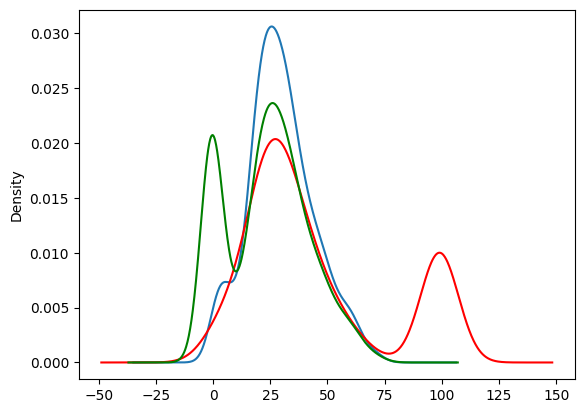

In [27]:
fig = plt.figure()
ax = fig.add_subplot(111)
x_train['Age'].plot(kind = 'kde' , ax=ax )
x_train['Age_99'].plot(kind = 'kde' , ax=ax , color ='red' )
x_train['Age_Minus_1'].plot(kind = 'kde' , ax=ax , color ='green' )

In [28]:
x_train.cov()

,Age,Fare,Age_Mean,Age_Median,Age_99,Age_Minus_1
Age,204.349513,71.512440,204.349513,204.349513,204.349513,204.349513
Fare,71.512440,2368.246832,56.626587,58.986531,-101.053412,126.761454
Age_Mean,204.349513,56.626587,161.812625,161.812625,161.812625,161.812625
Age_Median,204.349513,58.986531,161.812625,161.989566,149.990232,167.071135
Age_99,204.349513,-101.053412,161.812625,149.990232,951.727557,-189.535540
Age_Minus_1,204.349513,126.761454,161.812625,167.071135,-189.535540,318.089620


In [29]:
x_train.corr()

,Age,Fare,Age_Mean,Age_Median,Age_99,Age_Minus_1
Age,1.000000,0.095814,1.000000,1.000000,1.000000,1.000000
Fare,0.095814,1.000000,0.091475,0.095235,-0.067310,0.146049
Age_Mean,1.000000,0.091475,1.000000,0.999454,0.412335,0.713233
Age_Median,1.000000,0.095235,0.999454,1.000000,0.382000,0.736009
Age_99,1.000000,-0.067310,0.412335,0.382000,1.000000,-0.344476
Age_Minus_1,1.000000,0.146049,0.713233,0.736009,-0.344476,1.000000


In [30]:
imputer3 = SimpleImputer(strategy= 'constant' , fill_value=99)
imputer4 = SimpleImputer(strategy= 'constant' , fill_value=999)

In [31]:
trf2 = ColumnTransformer([
    ('imputer3' , imputer3 , ['Age']),
    ('imputer4' , imputer4 , ['Age'])
],remainder='passthrough')

In [32]:
trf2.fit(x_train)

,transformers,"[('imputer3', ...), ('imputer4', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'constant'
,fill_value,99


In [33]:
x_train

,Age,Fare,Age_Mean,Age_Median,Age_99,Age_Minus_1
30,40.0,27.7208,40.000000,40.00,40.0,40.0
10,4.0,16.7000,4.000000,4.00,4.0,4.0
873,47.0,9.0000,47.000000,47.00,47.0,47.0
182,9.0,31.3875,9.000000,9.00,9.0,9.0
876,20.0,9.8458,20.000000,20.00,20.0,20.0
...,...,...,...,...,...,...
534,30.0,8.6625,30.000000,30.00,30.0,30.0
584,NaN,8.7125,29.785904,28.75,99.0,-1.0
493,71.0,49.5042,71.000000,71.00,71.0,71.0
527,NaN,221.7792,29.785904,28.75,99.0,-1.0


In [35]:
trf2.named_transformers_['imputer3'].statistics_

array([99.])

In [36]:
x_train = trf.transform(x_train)

In [39]:
x_train

array([[ 40.        ,  40.        ,  27.7208    ,  40.        ,
         40.        ],
       [  4.        ,   4.        ,  16.7       ,   4.        ,
          4.        ],
       [ 47.        ,  47.        ,   9.        ,  47.        ,
         47.        ],
       ...,
       [ 71.        ,  71.        ,  49.5042    ,  71.        ,
         71.        ],
       [ 29.78590426,  28.75      , 221.7792    ,  29.78590426,
         28.75      ],
       [ 29.78590426,  28.75      ,  25.925     ,  29.78590426,
         28.75      ]], shape=(712, 5))